In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import lineStyles

In [2]:
df_all = pd.read_csv("../datasets_raw/offshore_dataset/Hollandse_Kust_Zuid.csv")

In [3]:
df_all['time'] = pd.to_datetime(df_all['time'])
df_2019 = df_all[df_all['time'].dt.year == 2019]

In [4]:
print(df_2019.columns)

Index(['Unnamed: 0', 'time', 'u100', 'v100', 'fsr', 'Windspeed',
       'Scaled_Windspeed_(at_125.5m)', 'Wind_Direction',
       'Power_of_SG 11.0-200 DD', 'Turn_off', 'Power'],
      dtype='str')


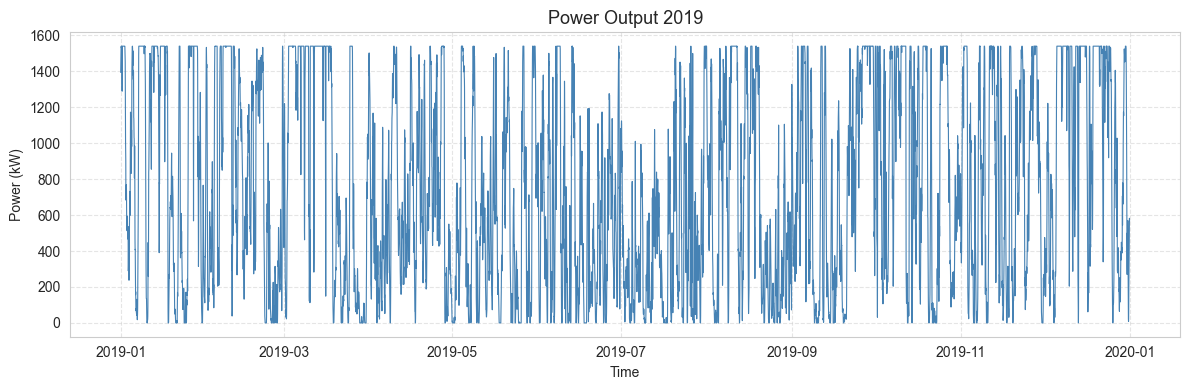

In [5]:
fig1, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(df_2019['time'], df_2019['Power'], color='steelblue', linewidth=0.8)
ax1.set_title('Power Output 2019', fontsize=13)
ax1.set_xlabel('Time')
ax1.set_ylabel('Power (kW)')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

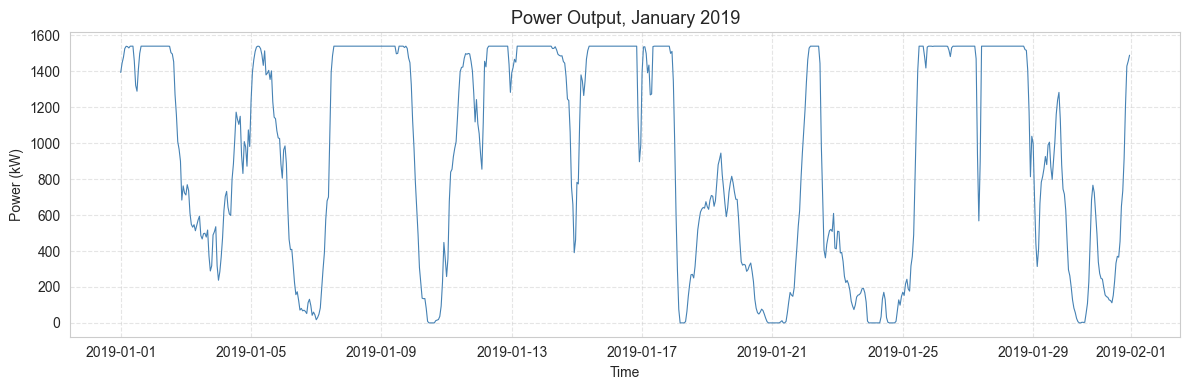

In [6]:
# Filter to the first month of 2019
mask = (df_2019['time'] >= '2019-01-01') & (df_2019['time'] < '2019-02-01')
df_jan = df_2019[mask]

fig1, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(df_jan['time'], df_jan['Power'], color='steelblue', linewidth=0.8)
ax1.set_title('Power Output, January 2019', fontsize=13)
ax1.set_xlabel('Time')
ax1.set_ylabel('Power (kW)')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

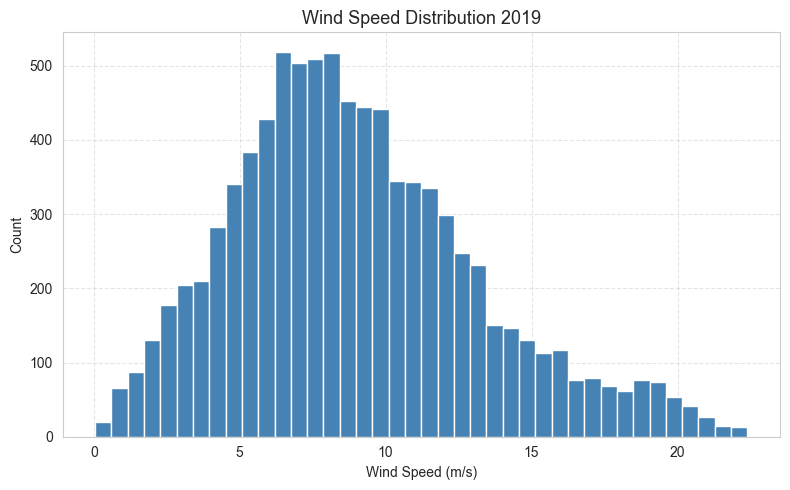

In [7]:
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.hist(df_2019['Windspeed'], bins=40, color='steelblue', edgecolor='white')
ax2.set_title('Wind Speed Distribution 2019', fontsize=13)
ax2.set_xlabel('Wind Speed (m/s)')
ax2.set_ylabel('Count')
ax2.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

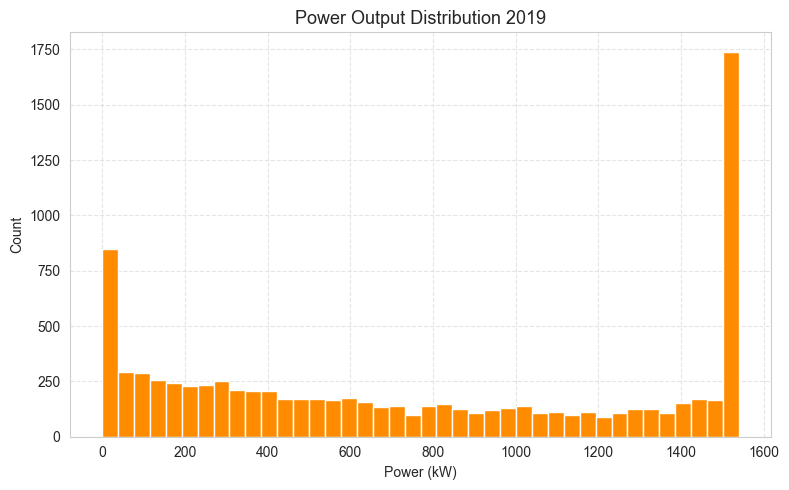

In [8]:
fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.hist(df_2019['Power'], bins=40, color='darkorange', edgecolor='white')
ax3.set_title('Power Output Distribution 2019', fontsize=13)
ax3.set_xlabel('Power (kW)')
ax3.set_ylabel('Count')
ax3.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

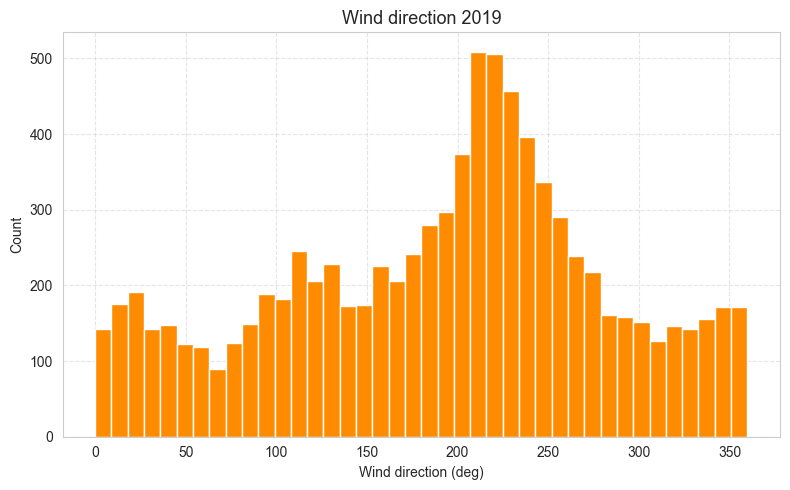

In [9]:
fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.hist(df_2019['Wind_Direction'], bins=40, color='darkorange', edgecolor='white')
ax3.set_title('Wind direction 2019', fontsize=13)
ax3.set_xlabel('Wind direction (deg)')
ax3.set_ylabel('Count')
ax3.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
# Calculate descriptive statistics
stats = df_2019[['Windspeed', "Wind_Direction", "Power"]].describe()
stats = stats.round(2)
print(stats)

       Windspeed  Wind_Direction    Power
count    8760.00         8760.00  8760.00
mean        8.98          190.38   768.56
std         4.24           90.15   565.03
min         0.05            0.04     0.00
25%         6.03          124.25   237.16
50%         8.43          206.01   685.41
75%        11.52          250.21  1398.06
max        22.39          359.88  1540.00


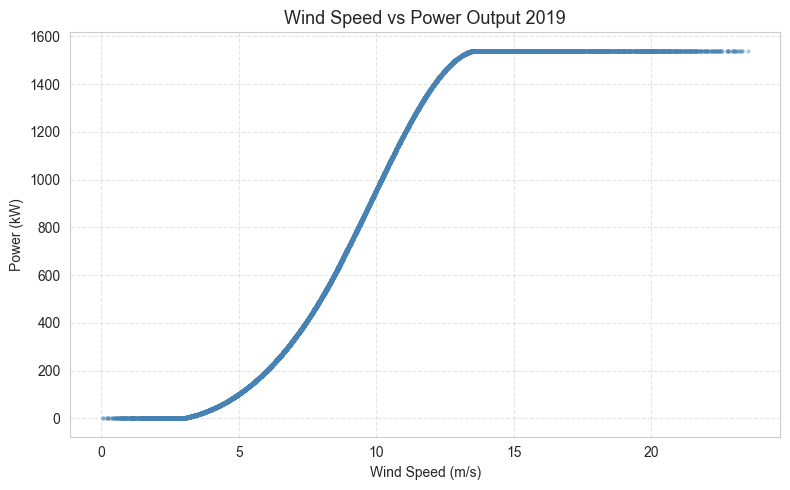

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_2019['Scaled_Windspeed_(at_125.5m)'], df_2019['Power'], alpha=0.3, s=5, color='steelblue')
ax.set_title('Wind Speed vs Power Output 2019', fontsize=13)
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (kW)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Investigation Windspeed vs Scaled Windspeed

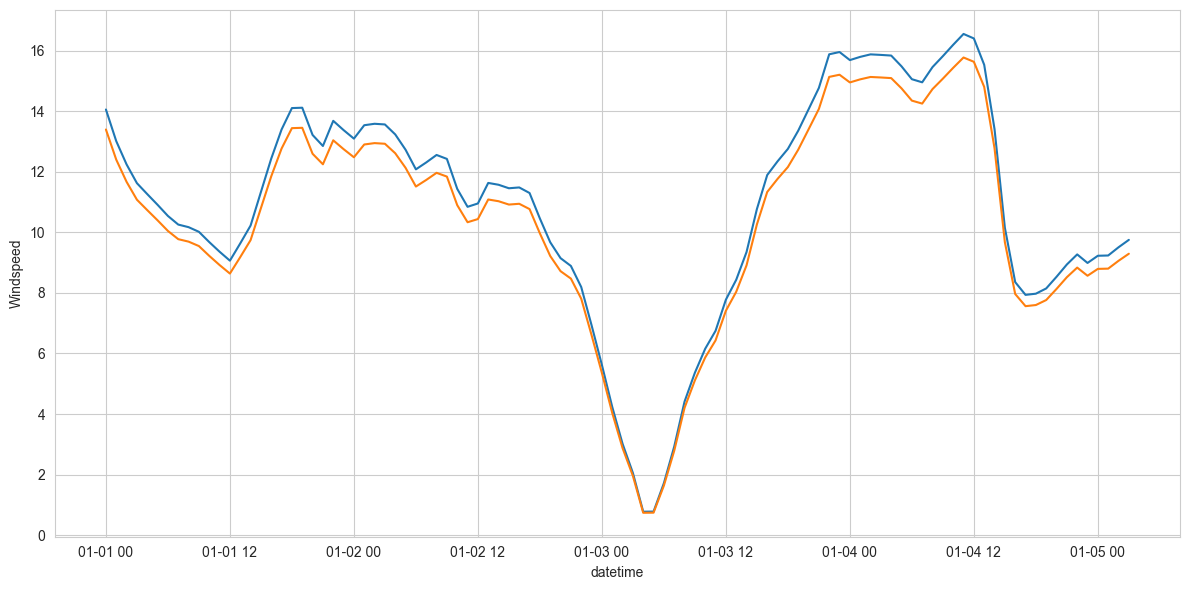

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_all["time"][:100], df_all["Scaled_Windspeed_(at_125.5m)"][:100])
ax.plot(df_all["time"][:100], df_all["Windspeed"][:100])
ax.set_xlabel("datetime")
ax.set_ylabel("Windspeed")
plt.tight_layout()
plt.show()

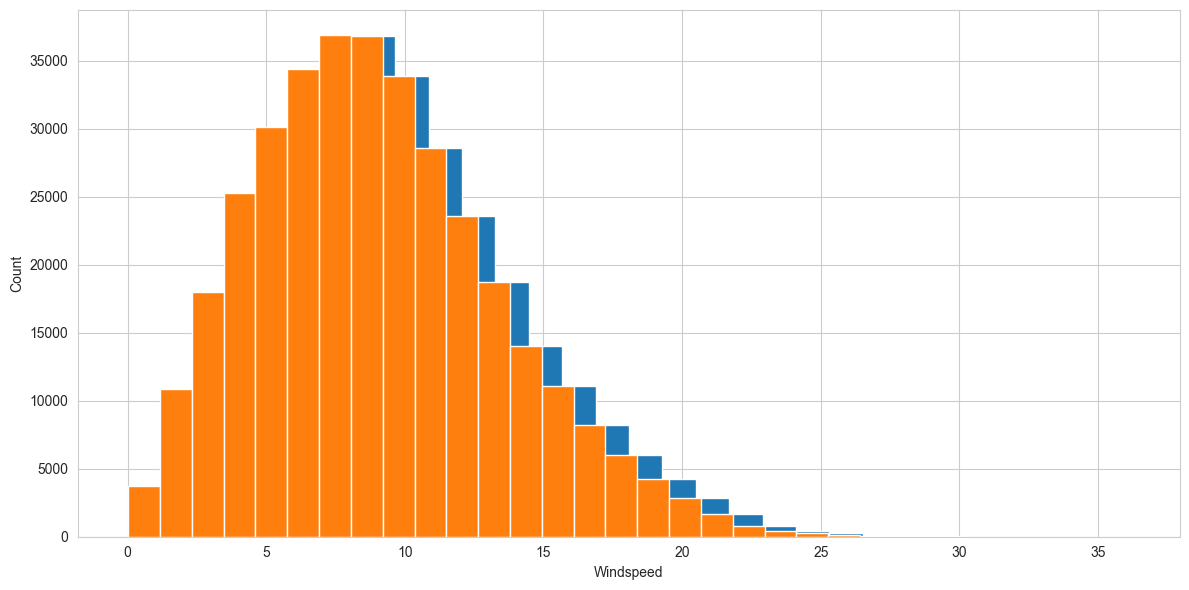

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df_all["Scaled_Windspeed_(at_125.5m)"], bins=30)
ax.hist(df_all["Windspeed"], bins=30)

ax.set_xlabel("Windspeed")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

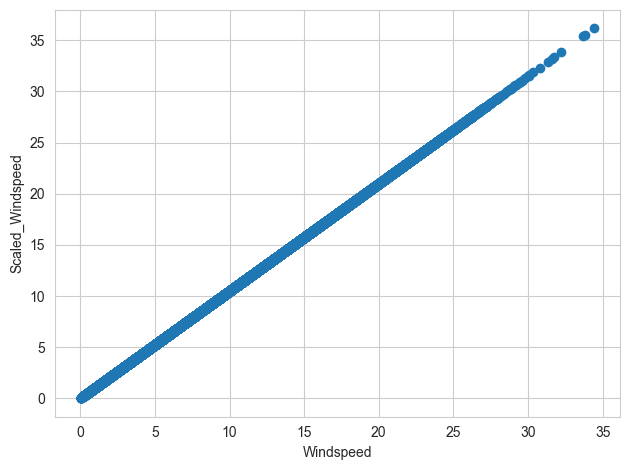

In [14]:
plt.scatter(df_all["Windspeed"], df_all["Scaled_Windspeed_(at_125.5m)"])
plt.xlabel("Windspeed")
plt.ylabel("Scaled_Windspeed")
plt.tight_layout()
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression
X = df_all["Windspeed"].to_numpy().reshape(-1, 1)
y = df_all["Scaled_Windspeed_(at_125.5m)"].to_numpy()
reg = LinearRegression().fit(X, y)
print(reg.score(X, y))
print(reg.coef_)

0.9999999998704873
[1.04933424]


# Investigate scaled windspeed for all wind farms

In [16]:
import json
import numpy as np
from scipy.stats import linregress

In [20]:
with open("../metadata_wind_farms.json") as f:
    wind_farms_metadata = json.load(f)["wind_farms"]
dict_offshore_dfs = {}
for wind_farm in wind_farms_metadata:
    if wind_farm.get("offshore_data_available", False):
        wind_farm_id = wind_farm.get("id")
        df = pd.read_csv("../datasets/offshore_"+wind_farm_id+".csv")
        dict_offshore_dfs[wind_farm_id] = df

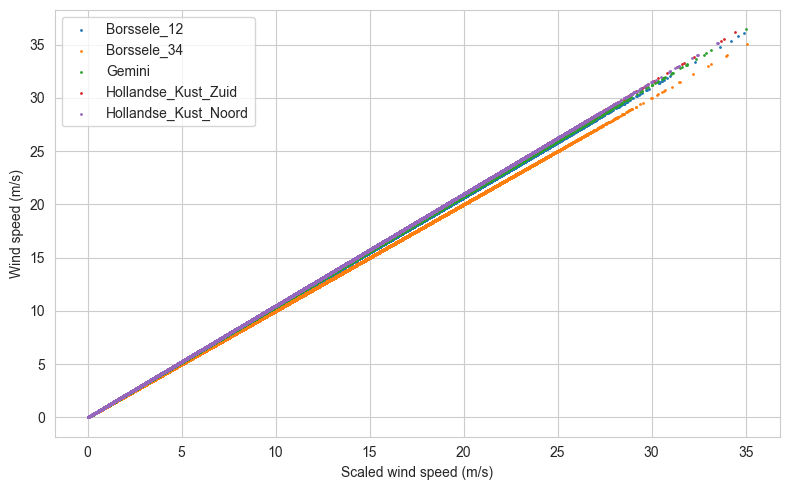

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

for name, df in dict_offshore_dfs.items():
    ax.scatter(df["Windspeed"], df["Scaled_Windspeed"], s=1, alpha=1, label=name)

ax.set_xlabel("Scaled wind speed (m/s)")
ax.set_ylabel("Wind speed (m/s)")
ax.legend()
plt.tight_layout()
plt.show()

slope=1.034, intercept=-0.000, R²=0.998


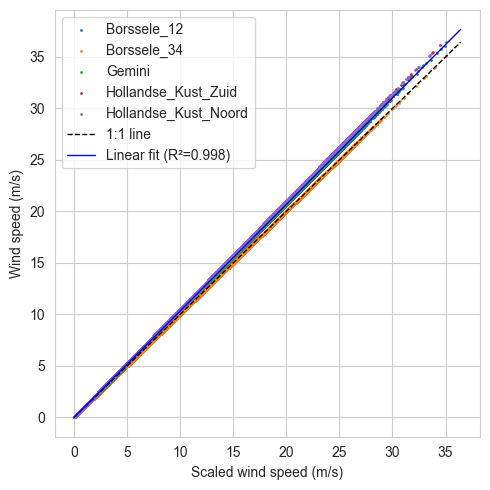

In [27]:


# combine all farms
all_scaled = np.concatenate([df["Scaled_Windspeed"].values for df in dict_offshore_dfs.values()])
all_wind = np.concatenate([df["Windspeed"].values for df in dict_offshore_dfs.values()])

# remove NaNs
mask = ~np.isnan(all_scaled) & ~np.isnan(all_wind)
all_scaled, all_wind = all_scaled[mask], all_wind[mask]

# fit
slope, intercept, r_value, p_value, std_err = linregress(all_wind, all_scaled)
print(f"slope={slope:.3f}, intercept={intercept:.3f}, R²={r_value**2:.3f}")

# plot
fig, ax = plt.subplots(figsize=(5, 5))

for name, df in dict_offshore_dfs.items():
    ax.scatter(df["Windspeed"], df["Scaled_Windspeed"], s=1, alpha=1, label=name)

x_range = np.linspace(all_scaled.min(), all_scaled.max(), 100)
ax.plot(x_range, 1 * x_range + 0, color="black", linewidth=1, label=f"1:1 line", linestyle="dashed")
ax.plot(x_range, slope * x_range + intercept, color="b", linewidth=1, label=f"Linear fit (R²={r_value**2:.3f})")

ax.set_xlabel("Scaled wind speed (m/s)")
ax.set_ylabel("Wind speed (m/s)")
ax.legend()
plt.tight_layout()
plt.show()

slope=1.000, intercept=0.000, R²=1.000


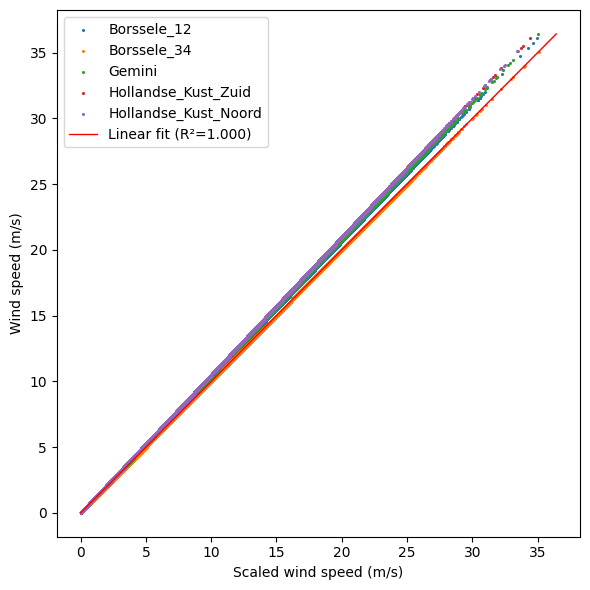

In [40]:


# combine all farms
scaled_borssele34 = dict_offshore_dfs["Borssele_34"]["Scaled_Windspeed"]
wind_borssele34 = dict_offshore_dfs["Borssele_34"]["Windspeed"]

# fit
slope, intercept, r_value, p_value, std_err = linregress(wind_borssele34, scaled_borssele34)
print(f"slope={slope:.3f}, intercept={intercept:.3f}, R²={r_value**2:.3f}")

# plot
fig, ax = plt.subplots(figsize=(6, 6))

for name, df in dict_offshore_dfs.items():
    ax.scatter(df["Windspeed"], df["Scaled_Windspeed"], s=1.5, alpha=1, label=name)

x_range = np.linspace(all_scaled.min(), all_scaled.max(), 100)
ax.plot(x_range, slope * x_range + intercept, color="red", linewidth=1, label=f"Linear fit (R²={r_value**2:.3f})")

ax.set_xlabel("Scaled wind speed (m/s)")
ax.set_ylabel("Wind speed (m/s)")
ax.legend()
plt.tight_layout()
plt.show()